# Detección Multiclase de Enfermedades Vegetales con Transfer Learning

## 1. Planteamiento del Problema y Objetivos

Este cuaderno desarrolla un sistema de clasificación multiclase de enfermedades foliares sobre PlantVillage, en el marco de visión por computador para agricultura de precisión.

Objetivo principal: comparar arquitecturas CNN preentrenadas bajo un protocolo experimental homogéneo y seleccionar el mejor compromiso entre calidad predictiva y coste computacional.

Objetivos específicos:
- Diseñar un pipeline reproducible de datos, entrenamiento y evaluación.
- Controlar sesgos por desbalance de clases mediante loss ponderada y métricas macro.
- Analizar rendimiento global y por clase, incluyendo patrones de error.
- Exponer el modelo final mediante una interfaz de inferencia interactiva.

Flujo experimental del cuaderno:
1. Configuración reproducible del entorno.
2. Curación y particionamiento estratificado de datos.
3. Entrenamiento comparativo con transfer learning en dos etapas.
4. Evaluación rigurosa en test independiente.
5. Despliegue con Gradio.

El dataset utilizado en esta práctica está disponible en Kaggle, en esta dirección: 
https://www.kaggle.com/datasets/mohitsingh1804/plantvillage
Asegúrense que se descomprime en el mismo nivel que el notebook. 

In [36]:
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import resnet50, efficientnet_b0
from PIL import Image
import gradio as gr
import os
import time
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

In [37]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Torch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.5.1+cu121
Device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [38]:
EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 5
SAVE_DIR = Path("./working/checkpoints")
SAVE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = MODEL_NAME if 'MODEL_NAME' in globals() else 'resnet50'
MODEL_PATH = f"./working/checkpoints/best_{MODEL_NAME}.pth"
CLASS_JSON_PATH = "./working/metadata/class_to_idx.json"

In [39]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            outputs = model(images)
            loss = criterion(outputs, labels)
            preds = outputs.argmax(dim=1)

            if is_train:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")

    return epoch_loss, epoch_acc, epoch_f1

## 2. Configuración Experimental y Reproducibilidad

La reproducibilidad es un requisito metodológico central en aprendizaje automático. Para ello se fija una semilla global y se unifica la configuración base del experimento.

En esta sección se establece:
- Importación de dependencias para datos, entrenamiento, evaluación y visualización.
- Definición de hiperparámetros globales y rutas de trabajo.
- Implementación de run_epoch como rutina común para entrenamiento y validación.
- Detección de dispositivo de cómputo (CPU/GPU) para ejecutar todo el pipeline en una configuración consistente.

## 3. Verificación Inicial del Dataset

Antes de construir el pipeline, se valida la estructura del conjunto PlantVillage para garantizar que el entrenamiento parte de entradas consistentes.

Chequeos realizados:
- Existencia y accesibilidad de la ruta base.
- Enumeración de carpetas de clase disponibles.
- Conteo preliminar de categorías para confirmar el espacio de etiquetas.

In [40]:
DATA_DIR = Path("./PlantVillage")

print("DATA_DIR exists:", DATA_DIR.exists())

classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print("Número de clases:", len(classes))
print("Lista de clases:", classes[:10])

DATA_DIR exists: True
Número de clases: 15
Lista de clases: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot']


## 4. Catalogación Estructurada de Muestras

Se construye una tabla maestra con el inventario de imágenes, donde cada fila contiene la ruta del archivo y su clase textual.

Este formato tabular habilita:
- Trazabilidad de cada muestra durante todo el experimento.
- Operaciones vectorizadas para auditoría y análisis exploratorio.
- Particiones estratificadas reproducibles sin manipulación manual de carpetas.

In [41]:
records = []

for cls in classes:
    cls_dir = DATA_DIR / cls
    for f in cls_dir.iterdir():
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]:
            records.append({
                "filepath": str(f),
                "class_name": cls
            })

df = pd.DataFrame(records)

print("Total de imágenes:", len(df))
df.head(20)

Total de imágenes: 20638


,filepath,class_name
0,PlantVillage\Pepper__bell___Bacterial_spot\002...,Pepper__bell___Bacterial_spot
1,PlantVillage\Pepper__bell___Bacterial_spot\006...,Pepper__bell___Bacterial_spot
2,PlantVillage\Pepper__bell___Bacterial_spot\00f...,Pepper__bell___Bacterial_spot
3,PlantVillage\Pepper__bell___Bacterial_spot\016...,Pepper__bell___Bacterial_spot
4,PlantVillage\Pepper__bell___Bacterial_spot\016...,Pepper__bell___Bacterial_spot
5,PlantVillage\Pepper__bell___Bacterial_spot\018...,Pepper__bell___Bacterial_spot
6,PlantVillage\Pepper__bell___Bacterial_spot\019...,Pepper__bell___Bacterial_spot
7,PlantVillage\Pepper__bell___Bacterial_spot\01d...,Pepper__bell___Bacterial_spot
8,PlantVillage\Pepper__bell___Bacterial_spot\01e...,Pepper__bell___Bacterial_spot
9,PlantVillage\Pepper__bell___Bacterial_spot\024...,Pepper__bell___Bacterial_spot


### 4.1 Codificación de Etiquetas

Los modelos supervisados requieren etiquetas enteras. Se define un mapeo biyectivo:
- class_to_idx: clase textual a índice entero.
- idx_to_class: índice entero a clase textual.

Con ello se añade la columna label al catálogo y se preserva la interpretabilidad en evaluación e inferencia.

In [42]:
class_to_idx = {cls: i for i, cls in enumerate(sorted(df["class_name"].unique()))}
idx_to_class = {i: cls for cls, i in class_to_idx.items()}

df["label"] = df["class_name"].map(class_to_idx)

print("Número de clases:", len(class_to_idx))
df.head(20)

Número de clases: 15


Número de clases: 15


,filepath,class_name,label
0,PlantVillage\Pepper__bell___Bacterial_spot\002...,Pepper__bell___Bacterial_spot,0
1,PlantVillage\Pepper__bell___Bacterial_spot\006...,Pepper__bell___Bacterial_spot,0
2,PlantVillage\Pepper__bell___Bacterial_spot\00f...,Pepper__bell___Bacterial_spot,0
3,PlantVillage\Pepper__bell___Bacterial_spot\016...,Pepper__bell___Bacterial_spot,0
4,PlantVillage\Pepper__bell___Bacterial_spot\016...,Pepper__bell___Bacterial_spot,0
5,PlantVillage\Pepper__bell___Bacterial_spot\018...,Pepper__bell___Bacterial_spot,0
6,PlantVillage\Pepper__bell___Bacterial_spot\019...,Pepper__bell___Bacterial_spot,0
7,PlantVillage\Pepper__bell___Bacterial_spot\01d...,Pepper__bell___Bacterial_spot,0
8,PlantVillage\Pepper__bell___Bacterial_spot\01e...,Pepper__bell___Bacterial_spot,0
9,PlantVillage\Pepper__bell___Bacterial_spot\024...,Pepper__bell___Bacterial_spot,0


### 4.2 Convención Semántica de Clases en PlantVillage

PlantVillage nombra clases con el patrón Planta___Enfermedad. Esta codificación se descompone para separar taxón y patología, mejorando:
- Legibilidad en tablas y gráficos.
- Interpretación clínica de predicciones.
- Presentación final en la interfaz de usuario.

In [43]:
# ── Utilidad: descomponer nombre de clase PlantVillage ──────────────────────
# Las carpetas siguen el patrón  'Planta___Enfermedad'  (triple guión bajo)
# Ejemplo: 'Tomato___Early_blight'  →  planta='Tomato', disease='Early blight'

def parse_class_name(class_name):
    """Devuelve (planta, enfermedad) a partir del nombre de carpeta PlantVillage."""
    if '___' in class_name:
        plant, disease = class_name.split('___', 1)
        disease = disease.replace('_', ' ')
    else:
        plant = class_name
        disease = 'Desconocida'
    return plant.strip(), disease.strip()

def format_disease_label(class_name):
    """Formatea el nombre de clase para mostrar en la interfaz."""
    plant, disease = parse_class_name(class_name)
    return f"{plant} — {disease}"

# Vista previa del mapeo de enfermedades
print(f"{'Clase original':<50} {'Planta':<20} {'Enfermedad'}")
print('-' * 85)
for cls in list(class_to_idx.keys())[:10]:
    plant, disease = parse_class_name(cls)
    print(f"{cls:<50} {plant:<20} {disease}")


Clase original                                     Planta               Enfermedad
-------------------------------------------------------------------------------------
Pepper__bell___Bacterial_spot                      Pepper__bell         Bacterial spot
Pepper__bell___healthy                             Pepper__bell         healthy
Potato___Early_blight                              Potato               Early blight
Potato___Late_blight                               Potato               Late blight
Potato___healthy                                   Potato               healthy
Tomato_Bacterial_spot                              Tomato_Bacterial_spot Desconocida
Tomato_Early_blight                                Tomato_Early_blight  Desconocida
Tomato_Late_blight                                 Tomato_Late_blight   Desconocida
Tomato_Leaf_Mold                                   Tomato_Leaf_Mold     Desconocida
Tomato_Septoria_leaf_spot                          Tomato_Septoria_leaf_spot D

### 4.3 Distribución de Clases y Riesgo de Sesgo

Se cuantifica la frecuencia por clase para detectar desbalance. Este análisis es clave porque una alta accuracy agregada puede ocultar bajo rendimiento en clases minoritarias.

La evidencia de desbalance justifica el uso posterior de CrossEntropyLoss ponderada y el seguimiento de F1 macro.

In [44]:
df_counts = df["class_name"].value_counts().reset_index()
df_counts.columns = ["class_name", "num_images"]

print(df_counts)
print("Número total de imágenes:", df_counts["num_images"].sum())

                                     class_name  num_images
0         Tomato__Tomato_YellowLeaf__Curl_Virus        3208
1                         Tomato_Bacterial_spot        2127
2                            Tomato_Late_blight        1909
3                     Tomato_Septoria_leaf_spot        1771
4   Tomato_Spider_mites_Two_spotted_spider_mite        1676
5                                Tomato_healthy        1591
6                        Pepper__bell___healthy        1478
7                           Tomato__Target_Spot        1404
8                         Potato___Early_blight        1000
9                          Potato___Late_blight        1000
10                          Tomato_Early_blight        1000
11                Pepper__bell___Bacterial_spot         997
12                             Tomato_Leaf_Mold         952
13                  Tomato__Tomato_mosaic_virus         373
14                             Potato___healthy         152
Número total de imágenes: 20638


### 4.4 Visualización de Frecuencias por Clase

Se representa gráficamente el número de muestras por clase para identificar de forma inmediata:
- Clases mayoritarias con fuerte influencia en el gradiente.
- Clases escasas con mayor riesgo de infraajuste.
- Magnitud real del desbalance del problema.

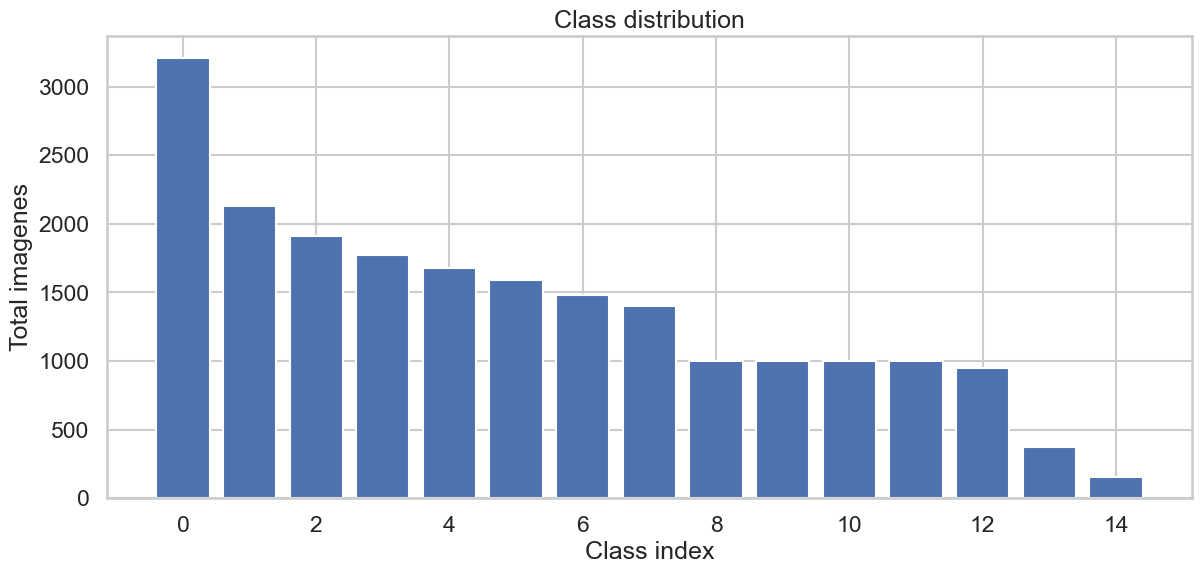

In [45]:
plt.figure(figsize=(14, 6))
plt.bar(range(len(df_counts)), df_counts["num_images"])
plt.title("Class distribution")
plt.xlabel("Class index")
plt.ylabel("Total imagenes")
plt.show()

### 4.6 Inspección Cualitativa de Muestras

La inspección visual complementa el análisis cuantitativo y permite evaluar:
- Variabilidad intraclase (misma enfermedad, distinta apariencia).
- Solapamiento visual entre clases potencialmente confusas.
- Artefactos de adquisición que pueden sesgar al modelo.

Estas observaciones guían decisiones sobre aumentación de datos y diseño de evaluación.

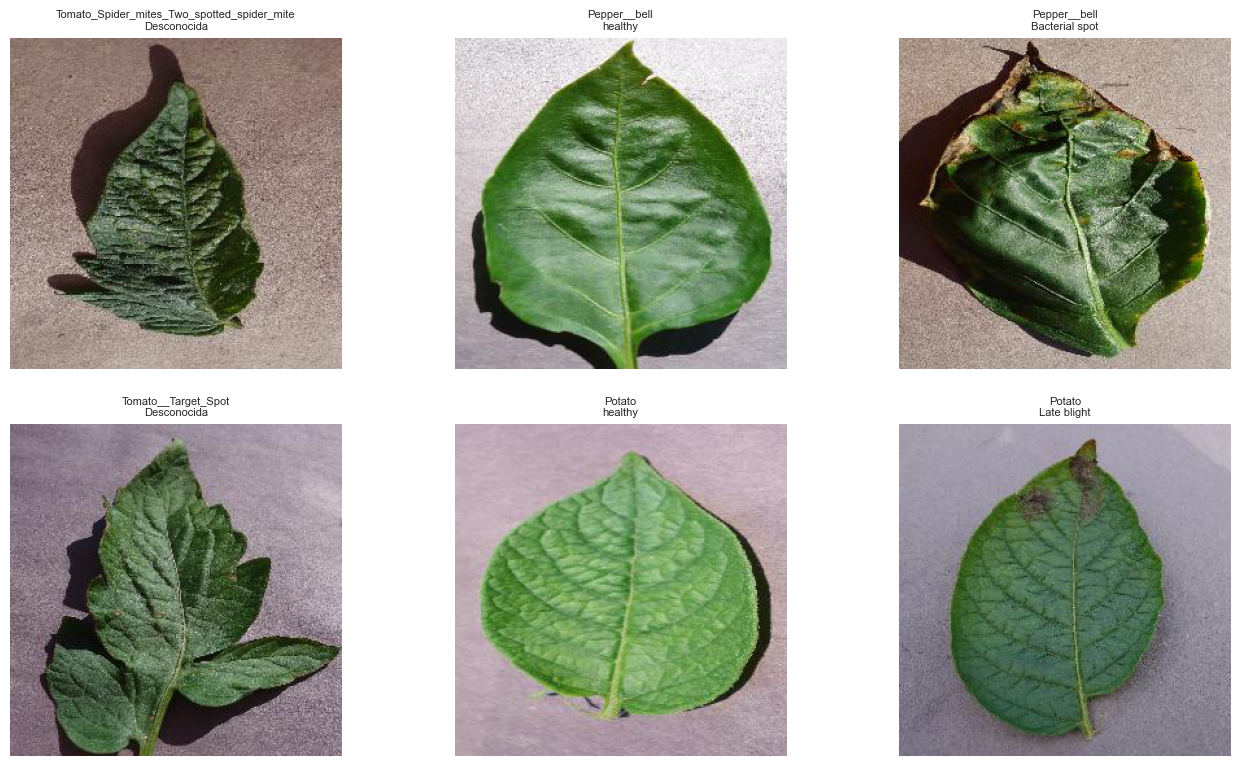

In [47]:
sample_classes = random.sample(classes, min(6, len(classes)))

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, cls in zip(axes, sample_classes):
    cls_dir = DATA_DIR / cls
    imgs = [f for f in cls_dir.iterdir() if f.suffix.lower() in [".jpg", ".jpeg", ".png"]]
    img_path = random.choice(imgs)
    img = Image.open(img_path).convert("RGB")

    ax.imshow(img)
    plant, disease = parse_class_name(cls) if "parse_class_name" in dir() else (cls, "")
    title = f"{plant}\n{disease}" if disease else cls
    ax.set_title(title, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Particionamiento Estratificado y Persistencia

Se genera una división 70/15/15 (train/val/test) con estratificación por etiqueta.

Razones metodológicas:
- Preservar la distribución de clases en todas las particiones.
- Evitar fuga de información entre entrenamiento y evaluación.
- Obtener estimaciones de generalización comparables entre arquitecturas.

In [48]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (14446, 3)
Val: (3096, 3)
Test: (3096, 3)


### 5.1 Persistencia de Particiones

Las particiones se almacenan en CSV para fijar un protocolo experimental estable y auditable. Esto permite repetir experimentos exactamente sobre el mismo conjunto de muestras.

In [49]:
SPLIT_DIR = Path("./working/splits")
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

train_df.to_csv(SPLIT_DIR / "train.csv", index=False)
val_df.to_csv(SPLIT_DIR / "val.csv", index=False)
test_df.to_csv(SPLIT_DIR / "test.csv", index=False)

print("División guardada en:", SPLIT_DIR)

División guardada en: working\splits


### 5.2 Persistencia del Espacio de Etiquetas

Se serializa class_to_idx para garantizar consistencia entre entrenamiento e inferencia. Sin este mapeo, una predicción numérica carece de significado clínico-operativo.

In [50]:
META_DIR = Path("./working/metadata")
META_DIR.mkdir(parents=True, exist_ok=True)

with open(META_DIR / "class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=2)

print("Archivo de clase a idx creado: class_to_idx.json")

Archivo de clase a idx creado: class_to_idx.json


### 5.3 Control de Calidad de Imagen

Se audita una muestra representativa para verificar supuestos del pipeline:
- Modos de color y necesidad de conversión a RGB.
- Distribución de tamaños para justificar el resize.
- Detección de ficheros corruptos o ilegibles.

Este control reduce fallos silenciosos en entrenamiento y mejora la estabilidad experimental.

In [51]:
# ════════════════════════════════════════════════════════════════════════
# AUDITORÍA DE CALIDAD: Solo TRAIN set (después del split)
# ════════════════════════════════════════════════════════════════════════

train_df_loaded = pd.read_csv(SPLIT_DIR / "train.csv")
sample_train_df = train_df_loaded.sample(min(1000, len(train_df_loaded)), random_state=42).reset_index(drop=True)

widths, heights, modes, bad_files = [], [], [], []

for path in sample_train_df["filepath"]:
    try:
        with Image.open(path) as img:
            widths.append(img.width)
            heights.append(img.height)
            modes.append(img.mode)
    except Exception as e:
        bad_files.append(path)

print("=" * 60)
print("AUDITORÍA DE CALIDAD: TRAIN SET (prevención de data leakage)")
print("=" * 60)
print(f"Muestras auditadas (train): {len(sample_train_df)}")
print(f"Archivos con error: {len(bad_files)}")
print(f"Image mode counts: {Counter(modes)}")
print("\nEstadísticas de ancho:")
print(pd.Series(widths).describe())
print("\nEstadísticas de alto:")
print(pd.Series(heights).describe())

if bad_files:
    print(f"\n Se encontraron {len(bad_files)} archivos problemáticos:")
    for f in bad_files[:5]:
        print(f"  - {f}")
else:
    print("\n✓ No se detectaron archivos corruptos en el train set.")

AUDITORÍA DE CALIDAD: TRAIN SET (prevención de data leakage)
Muestras auditadas (train): 1000
Archivos con error: 0
Image mode counts: Counter({'RGB': 1000})

Estadísticas de ancho:
count    1000.0
mean      256.0
std         0.0
min       256.0
25%       256.0
50%       256.0
75%       256.0
max       256.0
dtype: float64

Estadísticas de alto:
count    1000.0
mean      256.0
std         0.0
min       256.0
25%       256.0
50%       256.0
75%       256.0
max       256.0
dtype: float64

✓ No se detectaron archivos corruptos en el train set.


## 6. Dataset de PyTorch y Carga Eficiente de Datos

Se implementa un Dataset personalizado para desacoplar lectura de ficheros, etiquetado y transformaciones.

Ventajas técnicas:
- Carga perezosa de imágenes (uso eficiente de memoria).
- Integración directa con DataLoader (batching, shuffle, multiproceso).
- Transformaciones on-the-fly diferenciadas para train y evaluación.

In [52]:
class PlantDiseaseCSVDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.df = pd.read_csv(csv_file)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

### 6.1 Hiperparámetros Base del Pipeline de Entrada

Configuración inicial:
- IMG_SIZE = 224, compatible con preentrenamiento ImageNet.
- BATCH_SIZE = 16, equilibrio entre estabilidad de gradiente y memoria.
- NUM_WORKERS = 0, opción robusta entre entornos.

Estos valores son el punto de partida y pueden ajustarse en la fase de optimización.

In [53]:
IMG_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0

### 6.2 Aumentación y Normalización

Transformaciones de entrenamiento:
- RandomResizedCrop, flips, rotaciones leves y jitter de color para robustez ante variaciones de adquisición.

Transformaciones de validación/test:
- Solo resize y normalización, sin estocasticidad, para una medición limpia.

Todas las entradas se normalizan con estadísticas de ImageNet para preservar la compatibilidad con pesos preentrenados.

In [54]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10, fill=128),
    transforms.ColorJitter(
        brightness=0.1,
        contrast=0.1,
        saturation=0.1,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### 6.3 Construcción de DataLoaders

Se crean DataLoaders para train, validación y test con políticas diferenciadas:
- train: shuffle activo para reducir correlación intraépoca.
- val/test: orden fijo para comparabilidad y depuración.
- pin_memory habilitado para acelerar transferencia a GPU cuando procede.

In [55]:
train_dataset = PlantDiseaseCSVDataset(SPLIT_DIR / "train.csv", transform=train_transform)
val_dataset   = PlantDiseaseCSVDataset(SPLIT_DIR / "val.csv", transform=val_test_transform)
test_dataset  = PlantDiseaseCSVDataset(SPLIT_DIR / "test.csv", transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
print("Train batches:", len(train_loader))

Train samples: 14446
Val samples: 3096
Test samples: 3096
Train batches: 903


### 6.4 Verificación Estructural de Batch

Se inspecciona un mini-batch para validar forma tensorial y consistencia de etiquetas antes del entrenamiento completo.

Este paso detecta tempranamente errores de codificación, tamaño o canal de imagen.

In [56]:
images, labels = next(iter(train_loader))
print("Images:", images.shape)
print("Labels:", labels.shape)
print("First labels:", labels[:10])

Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])
First labels: tensor([11,  6,  8, 12,  7,  9, 12,  8, 10, 14])


### 6.5 Compensación de Desbalance con Pesos de Clase

Para mitigar el sesgo hacia clases frecuentes se usa ponderación inversa de frecuencia en la función de pérdida:

$$w_c = \frac{N}{n_c \cdot C}$$

con $N$ número total de muestras, $n_c$ frecuencia de la clase $c$ y $C$ número de clases.

La ponderación mejora la sensibilidad en clases minoritarias y se documenta en metadatos para trazabilidad.

In [57]:
train_csv = pd.read_csv(SPLIT_DIR / "train.csv")
class_counts = Counter(train_csv["label"])

num_classes = train_csv["label"].nunique()
total_samples = len(train_csv)

class_weights = []
for i in range(num_classes):
    weight_i = total_samples / (num_classes * class_counts[i])
    class_weights.append(weight_i)

class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)

weights_df = pd.DataFrame({
    "label": list(range(num_classes)),
    "class_name": [idx_to_class[i] for i in range(num_classes)],
    "count": [class_counts[i] for i in range(num_classes)],
    "weight": class_weights.detach().cpu().numpy()
}).sort_values("count")

weights_df.to_csv(META_DIR / "class_weights.csv", index=False)
weights_df

,label,class_name,count,weight
4,4,Potato___healthy,106,9.085535
13,13,Tomato__Tomato_mosaic_virus,261,3.689911
8,8,Tomato_Leaf_Mold,666,1.446046
0,0,Pepper__bell___Bacterial_spot,698,1.379752
6,6,Tomato_Early_blight,700,1.375810
2,2,Potato___Early_blight,700,1.375810
3,3,Potato___Late_blight,700,1.375810
11,11,Tomato__Target_Spot,983,0.979722
1,1,Pepper__bell___healthy,1035,0.930499
14,14,Tomato_healthy,1114,0.864512


### 6.6 Control Visual Tras Denormalización

Se revierte temporalmente la normalización para inspeccionar muestras del batch en espacio visual humano.

Objetivo: confirmar que las transformaciones aplicadas son plausibles y no introducen artefactos que distorsionen la señal diagnóstica.

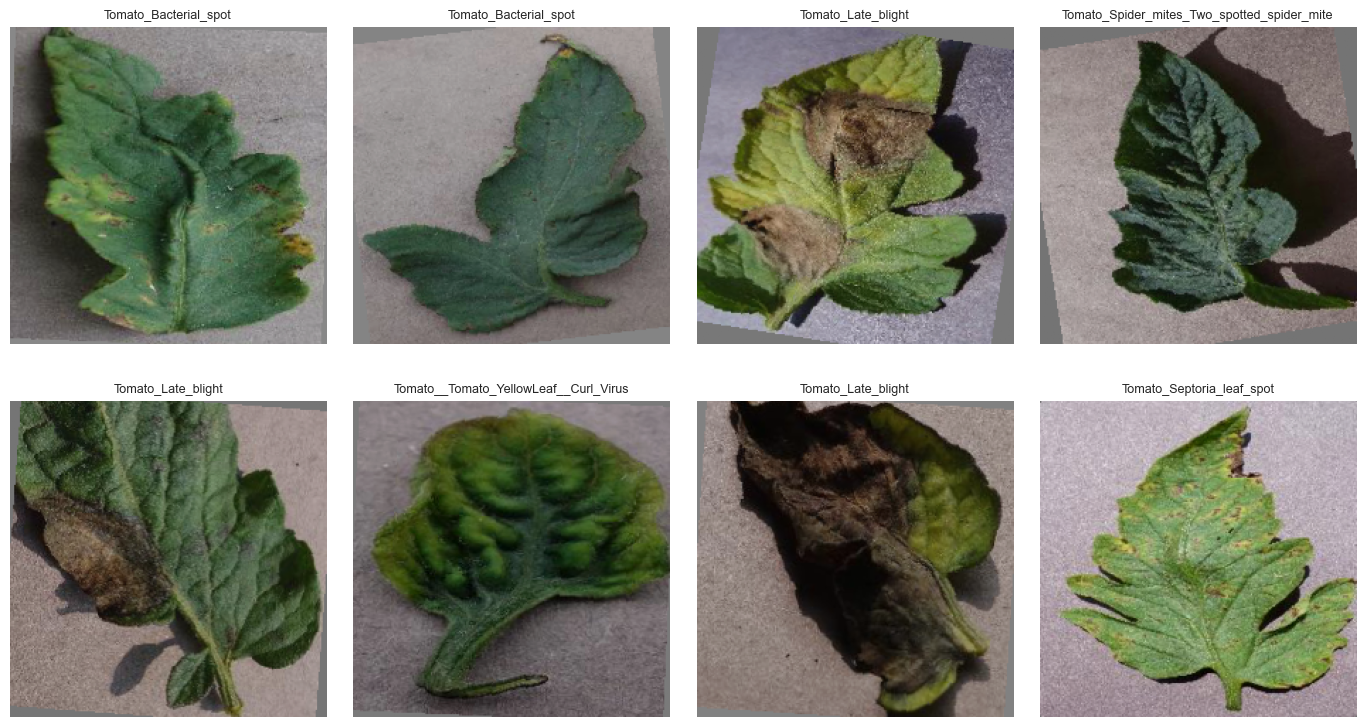

In [58]:
def unnormalize(img_tensor):
    img = img_tensor.detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img * std + mean
    img = torch.clamp(img, 0, 1)
    return img

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    label_name = idx_to_class[labels[i].item()]
    ax.imshow(img)
    ax.set_title(label_name, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 7. Modelado y Entrenamiento Comparativo

Se adopta transfer learning en dos fases:
- Fase 1 (feature extraction): capas base congeladas y entrenamiento de la cabeza clasificadora.
- Fase 2 (fine-tuning): descongelado global y ajuste con tasa de aprendizaje menor.

Configuración de optimización:
- AdamW con regularización por weight decay.
- ReduceLROnPlateau para ajuste adaptativo del learning rate.
- CrossEntropyLoss ponderada y label smoothing para mayor estabilidad y calibración.

### 7.1 Definición Paramétrica de Arquitecturas

Las arquitecturas se encapsulan en una estructura de configuración común que incluye inicialización, extracción de parámetros base y redefinición de la capa final.

Este diseño reduce duplicación, asegura condiciones homogéneas y facilita extender el estudio a nuevos modelos.

### 7.2 Protocolo de Entrenamiento y Selección

Cada arquitectura se entrena con el mismo procedimiento:
1. Entrenamiento de cabeza con extractor congelado.
2. Fine-tuning de todos los parámetros.
3. Monitorización de val_loss y guardado del mejor checkpoint.
4. Evaluación final en test independiente.

La comparación final se reporta mediante Loss, Accuracy, F1 macro y tiempo total.

In [82]:
# =========================
# ENTRENAMIENTO COMPARATIVO DE 3 MODELOS
# =========================
from torchvision.models import resnet50, efficientnet_b0

model_configs = [
    {
        'name': 'resnet50',
        'init_fn': lambda: resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'get_features': lambda m: m.parameters(),
        'get_classifier_in': lambda m: m.fc.in_features,
        'set_classifier': lambda m, in_f, n_cls: setattr(m, 'fc', nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, n_cls)))
    },
    {
        'name': 'efficientnet_b0',
        'init_fn': lambda: efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT),
        'get_features': lambda m: m.parameters(),
        'get_classifier_in': lambda m: m.classifier[1].in_features,
        'set_classifier': lambda m, in_f, n_cls: setattr(m.classifier, '1', nn.Sequential(nn.Dropout(0.4), nn.Linear(in_f, n_cls)))
    }
]

results = []
histories_by_model = {}

for config in model_configs:
    print(f"\n{'='*60}")
    print(f"Entrenando modelo: {config['name'].upper()}")
    print(f"{'='*60}")

    model = config['init_fn']()
    for param in config['get_features'](model):
        param.requires_grad = False
    in_features = config['get_classifier_in'](model)
    config['set_classifier'](model, in_features, num_classes)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
    optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    best_val_loss = float("inf")
    history = []
    checkpoint_filename = f"best_{config['name']}.pth"
    total_train_time = 0.0

    # =========================
    # ETAPA 1: Feature Extraction (Congelado)
    # =========================
    print(f"\n[ETAPA 1] Entrenamiento de cabeza clasificadora (features congeladas)...")
    for epoch in range(EPOCHS_STAGE1):
        epoch_start = time.time()
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)
        lr_epoch = optimizer.param_groups[0]["lr"]
        scheduler.step()
        total_train_time += time.time() - epoch_start

        history.append({
            "stage": 1, "epoch": epoch + 1, "lr": lr_epoch,
            "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1
        })

        print(
            f"  Epoch {epoch+1}/{EPOCHS_STAGE1} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | lr={lr_epoch:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "model_name": config['name']
            }, SAVE_DIR / checkpoint_filename)
            print(f"    ✓ Mejor modelo guardado (val_loss={val_loss:.4f})")

    # =========================
    # ETAPA 2: Fine-tuning (Todas las capas desbloqueadas)
    # =========================
    print(f"\n[ETAPA 2] Fine-tuning global (todas las capas desbloqueadas)...")
    for param in model.parameters():
        param.requires_grad = True
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.5)

    for epoch in range(EPOCHS_STAGE2):
        epoch_start = time.time()
        train_loss, train_acc, train_f1 = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1 = run_epoch(model, val_loader, criterion)
        lr_epoch = optimizer.param_groups[0]["lr"]
        scheduler.step()
        total_train_time += time.time() - epoch_start

        history.append({
            "stage": 2, "epoch": epoch + 1, "lr": lr_epoch,
            "train_loss": train_loss, "train_acc": train_acc, "train_f1": train_f1,
            "val_loss": val_loss, "val_acc": val_acc, "val_f1": val_f1
        })

        print(
            f"  Epoch {epoch+1}/{EPOCHS_STAGE2} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f} | lr={lr_epoch:.2e}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({
                "model_state_dict": model.state_dict(),
                "num_classes": num_classes,
                "model_name": config['name']
            }, SAVE_DIR / checkpoint_filename)
            print(f"    ✓ Mejor modelo guardado (val_loss={val_loss:.4f})")

    histories_by_model[config["name"]] = history.copy()

    # =========================
    # EVALUACIÓN EN TEST SET
    # =========================
    print(f"\n[EVALUACIÓN] Probando en test set...")
    checkpoint = torch.load(SAVE_DIR / checkpoint_filename, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    test_loss, test_acc, test_f1 = run_epoch(model, test_loader, criterion)

    results.append({
        "Modelo": config['name'],
        "Test Loss": test_loss,
        "Test Acc": test_acc,
        "Test F1": test_f1,
        "Total Time (s)": total_train_time
    })
    print(f"\n✓ {config['name'].upper()}: Loss={test_loss:.4f}, Acc={test_acc:.4f}, F1={test_f1:.4f}")

# =========================
# COMPARATIVA FINAL
# =========================
print(f"\n{'='*60}")
print("COMPARATIVA DE MODELOS EN TEST SET")
print(f"{'='*60}")
results_df = pd.DataFrame(results)
display(results_df.round(4))
results_df.to_csv(SAVE_DIR / "model_comparison.csv", index=False)


Entrenando modelo: RESNET50

[ETAPA 1] Entrenamiento de cabeza clasificadora (features congeladas)...


  0%|          | 0/903 [00:00<?, ?it/s]

  0%|          | 0/194 [00:00<?, ?it/s]

  Epoch 1/5 | train_loss=1.7167, train_acc=0.7268 | val_loss=1.3447, val_acc=0.8446 | lr=1.00e-03
    ✓ Mejor modelo guardado (val_loss=1.3447)


  0%|          | 0/903 [00:00<?, ?it/s]

...

  Epoch 5/5 | train_loss=0.9289, train_acc=0.9898 | val_loss=0.8872, val_acc=0.9968 | lr=2.50e-05
    ✓ Mejor modelo guardado (val_loss=0.8872)

[EVALUACIÓN] Probando en test set...


C:\Users\antca\AppData\Local\Temp\ipykernel_2128\4258838743.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(SAVE_DIR / checkpoint_filename, map

  0%|          | 0/194 [00:00<?, ?it/s]


✓ EFFICIENTNET_B0: Loss=0.8911, Acc=0.9945, F1=0.9912

COMPARATIVA DE MODELOS EN TEST SET


,Modelo,Test Loss,Test Acc,Test F1,Total Time (s)
0,resnet50,0.8727,0.9945,0.9889,6630.7406
1,efficientnet_b0,0.8911,0.9945,0.9912,1470.9325


Modelos en curvas: ['efficientnet_b0', 'resnet50']


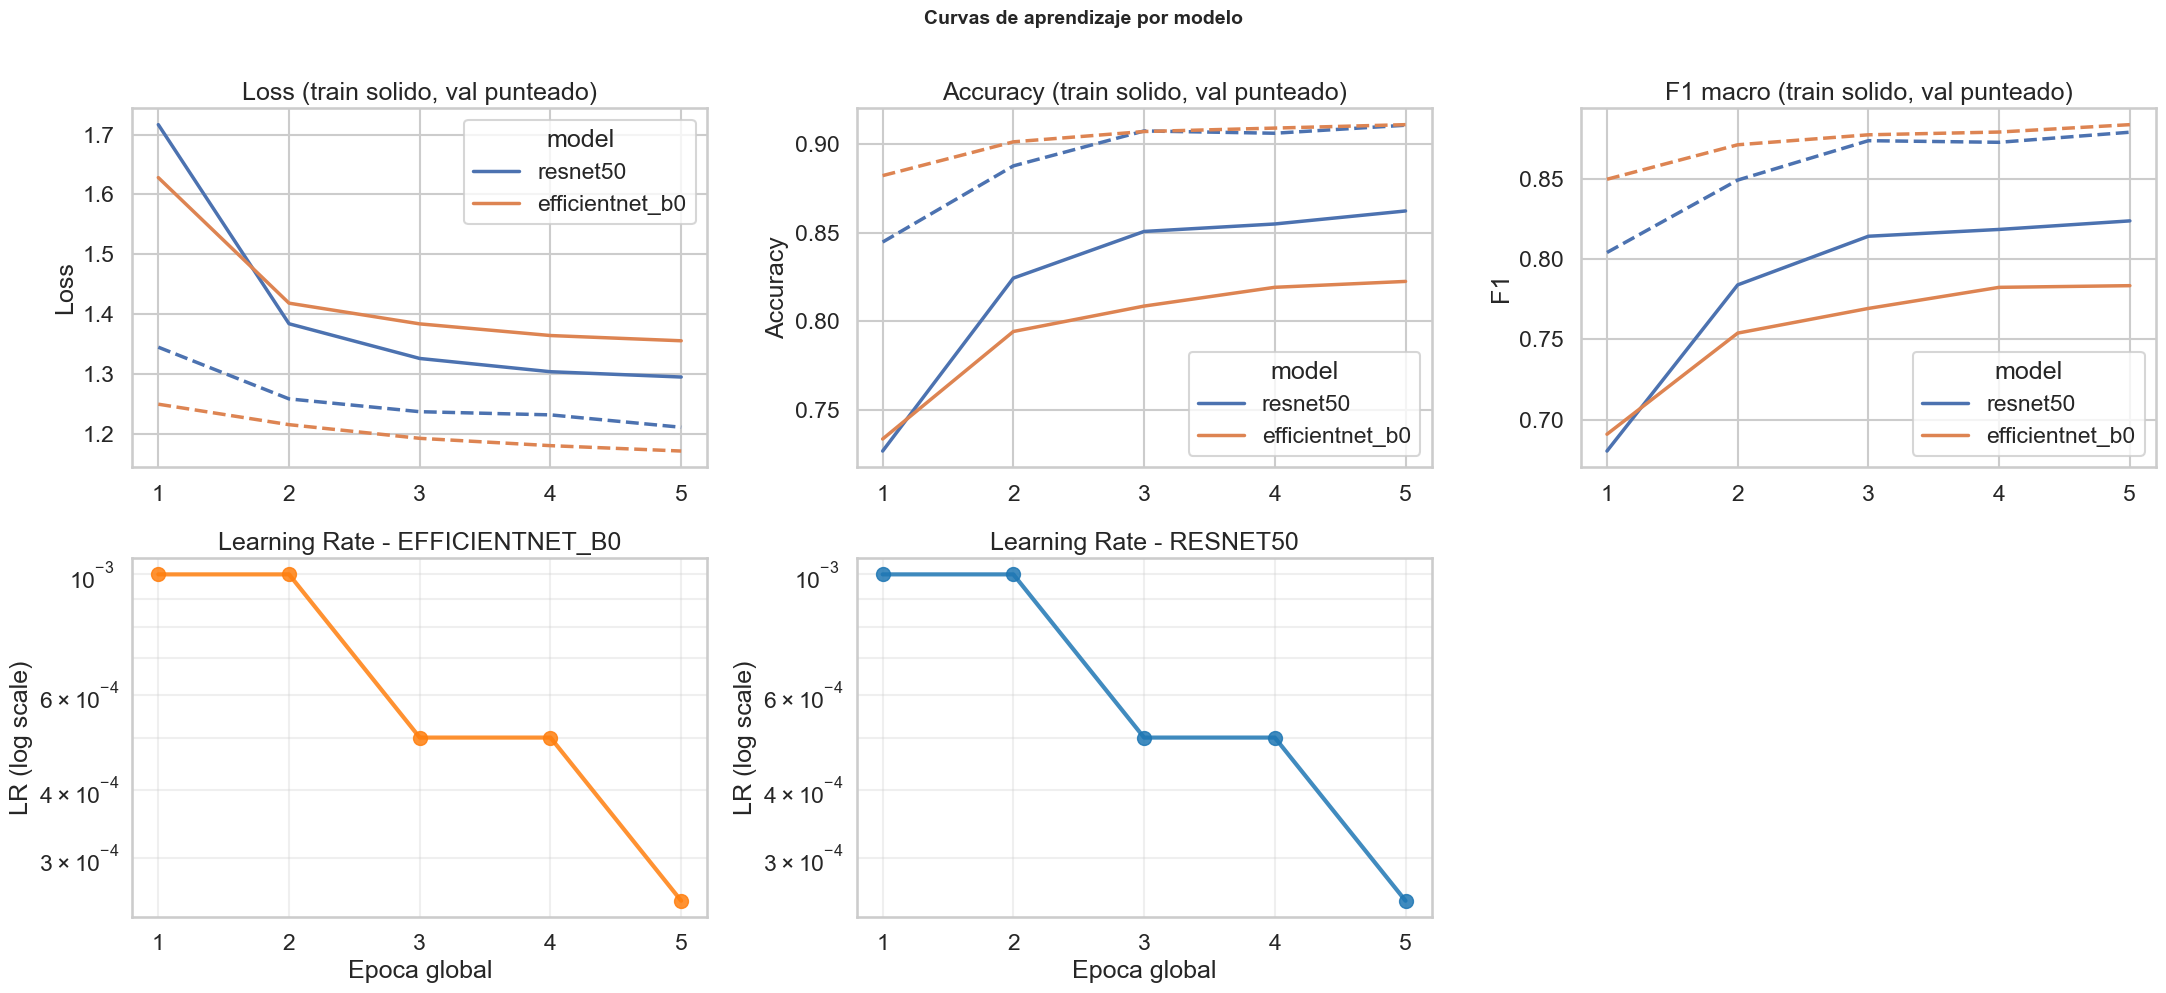

In [100]:
# Curvas de aprendizaje por modelo (Loss / Accuracy / F1 / Learning Rate separado)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", context="talk")

records = []

# Caso recomendado: historial completo por modelo
if "histories_by_model" in globals() and isinstance(histories_by_model, dict) and len(histories_by_model) > 0:
    for model_name, hist in histories_by_model.items():
        if not isinstance(hist, list):
            continue
        for row in hist:
            r = dict(row)
            r["model"] = model_name
            records.append(r)

# Fallback: historial disponible solo del ultimo modelo entrenado
elif "history" in globals() and isinstance(history, list) and len(history) > 0:
    model_name = "ultimo_modelo"
    if "config" in globals() and isinstance(config, dict) and "name" in config:
        model_name = config["name"]

    for row in history:
        r = dict(row)
        r["model"] = model_name
        records.append(r)

if not records:
    raise ValueError(
        "No se encontraron historiales de entrenamiento. "
        "Ejecuta primero la celda 46 para generar 'history' o 'histories_by_model'."
    )

hist_df = pd.DataFrame(records)
required_cols = [
    "stage", "epoch", "train_loss", "val_loss", "train_acc", "val_acc", "train_f1", "val_f1"
]
missing_cols = [c for c in required_cols if c not in hist_df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en el historial: {missing_cols}")

hist_df["stage"] = hist_df["stage"].astype(int)

# Eje temporal continuo para unir etapa 1 y etapa 2
hist_df["epoch_global"] = hist_df.groupby(["model", "stage"]).cumcount() + 1
stage1_len = hist_df[hist_df["stage"] == 1].groupby("model")["epoch_global"].transform("max").fillna(0)
hist_df.loc[hist_df["stage"] == 2, "epoch_global"] += stage1_len[hist_df["stage"] == 2].astype(int)

models_found = sorted(hist_df["model"].unique().tolist())
print(f"Modelos en curvas: {models_found}")

# Layout: 2 filas, 3 columnas
fig, axes = plt.subplots(2, 3, figsize=(22, 10), sharex="row")

# Fila 1: Loss, Accuracy, F1
sns.lineplot(data=hist_df, x="epoch_global", y="train_loss", hue="model", ax=axes[0, 0], linewidth=2.5)
sns.lineplot(data=hist_df, x="epoch_global", y="val_loss", hue="model", ax=axes[0, 0], linewidth=2.5, linestyle="--", legend=False)
axes[0, 0].set_title("Loss (train solido, val punteado)")
axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_xlabel("")

sns.lineplot(data=hist_df, x="epoch_global", y="train_acc", hue="model", ax=axes[0, 1], linewidth=2.5)
sns.lineplot(data=hist_df, x="epoch_global", y="val_acc", hue="model", ax=axes[0, 1], linewidth=2.5, linestyle="--", legend=False)
axes[0, 1].set_title("Accuracy (train solido, val punteado)")
axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_xlabel("")

sns.lineplot(data=hist_df, x="epoch_global", y="train_f1", hue="model", ax=axes[0, 2], linewidth=2.5)
sns.lineplot(data=hist_df, x="epoch_global", y="val_f1", hue="model", ax=axes[0, 2], linewidth=2.5, linestyle="--", legend=False)
axes[0, 2].set_title("F1 macro (train solido, val punteado)")
axes[0, 2].set_ylabel("F1")
axes[0, 2].set_xlabel("")

# Fila 2: Learning Rate separado por modelo
if "lr" in hist_df.columns:
    lr_df = hist_df[["model", "epoch_global", "lr"]].dropna(subset=["lr"]).copy()
    
    if not lr_df.empty:
        colors_map = {"resnet50": "#1f77b4", "efficientnet_b0": "#ff7f0e"}
        
        for idx, model in enumerate(sorted(lr_df["model"].unique())):
            ax = axes[1, idx]
            data = lr_df[lr_df["model"] == model].sort_values("epoch_global")
            ax.plot(
                data["epoch_global"].values,
                data["lr"].values,
                marker="o",
                markersize=10,
                linewidth=3,
                color=colors_map.get(model),
                alpha=0.85
            )
            ax.set_yscale("log")
            ax.set_title(f"Learning Rate - {model.upper()}")
            ax.set_ylabel("LR (log scale)")
            ax.set_xlabel("Epoca global")
            ax.grid(True, alpha=0.3, which="both")
        
        # Ocultar tercera gráfica de la fila 2 si solo hay 2 modelos
        if len(models_found) == 2:
            axes[1, 2].axis("off")
    else:
        for ax in axes[1]:
            ax.text(0.5, 0.5, "Sin datos de LR", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
else:
    for ax in axes[1]:
        ax.text(0.5, 0.5, "No hay columna 'lr'", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")

plt.suptitle("Curvas de aprendizaje por modelo", fontsize=14, fontweight="bold", y=1.00)
plt.tight_layout()
plt.show()

In [97]:
# Debug: Verificar valores de LR guardados por modelo
if "histories_by_model" in globals() and isinstance(histories_by_model, dict):
    for model_name, hist in histories_by_model.items():
        print(f"\n=== {model_name.upper()} ===")
        for i, row in enumerate(hist):
            if "lr" in row:
                print(f"Epoch {row['epoch']} (Stage {row['stage']}): LR = {row['lr']:.2e}")
            if i >= 12:  # Mostrar solo primeros 12 valores
                break
else:
    print("No se encontró 'histories_by_model' en memoria.")


=== RESNET50 ===
Epoch 1 (Stage 1): LR = 1.00e-03
Epoch 2 (Stage 1): LR = 1.00e-03
Epoch 3 (Stage 1): LR = 5.00e-04
Epoch 4 (Stage 1): LR = 5.00e-04
Epoch 5 (Stage 1): LR = 2.50e-04
Epoch 1 (Stage 2): LR = 1.00e-04
Epoch 2 (Stage 2): LR = 1.00e-04
Epoch 3 (Stage 2): LR = 5.00e-05
Epoch 4 (Stage 2): LR = 5.00e-05
Epoch 5 (Stage 2): LR = 2.50e-05

=== EFFICIENTNET_B0 ===
Epoch 1 (Stage 1): LR = 1.00e-03
Epoch 2 (Stage 1): LR = 1.00e-03
Epoch 3 (Stage 1): LR = 5.00e-04
Epoch 4 (Stage 1): LR = 5.00e-04
Epoch 5 (Stage 1): LR = 2.50e-04
Epoch 1 (Stage 2): LR = 1.00e-04
Epoch 2 (Stage 2): LR = 1.00e-04
Epoch 3 (Stage 2): LR = 5.00e-05
Epoch 4 (Stage 2): LR = 5.00e-05
Epoch 5 (Stage 2): LR = 2.50e-05


### 7.3 Comparación Pre/Post Ajuste

Se analiza la variación de desempeño entre estado previo y posterior a la optimización para ResNet50 y EfficientNet-B0.

Variables comparadas:
- Test Loss (menor es mejor).
- Test Accuracy y Test F1 macro (mayor es mejor).
- Tiempo total de entrenamiento (menor es mejor).

Este bloque permite separar mejoras reales de posibles artefactos de configuración.

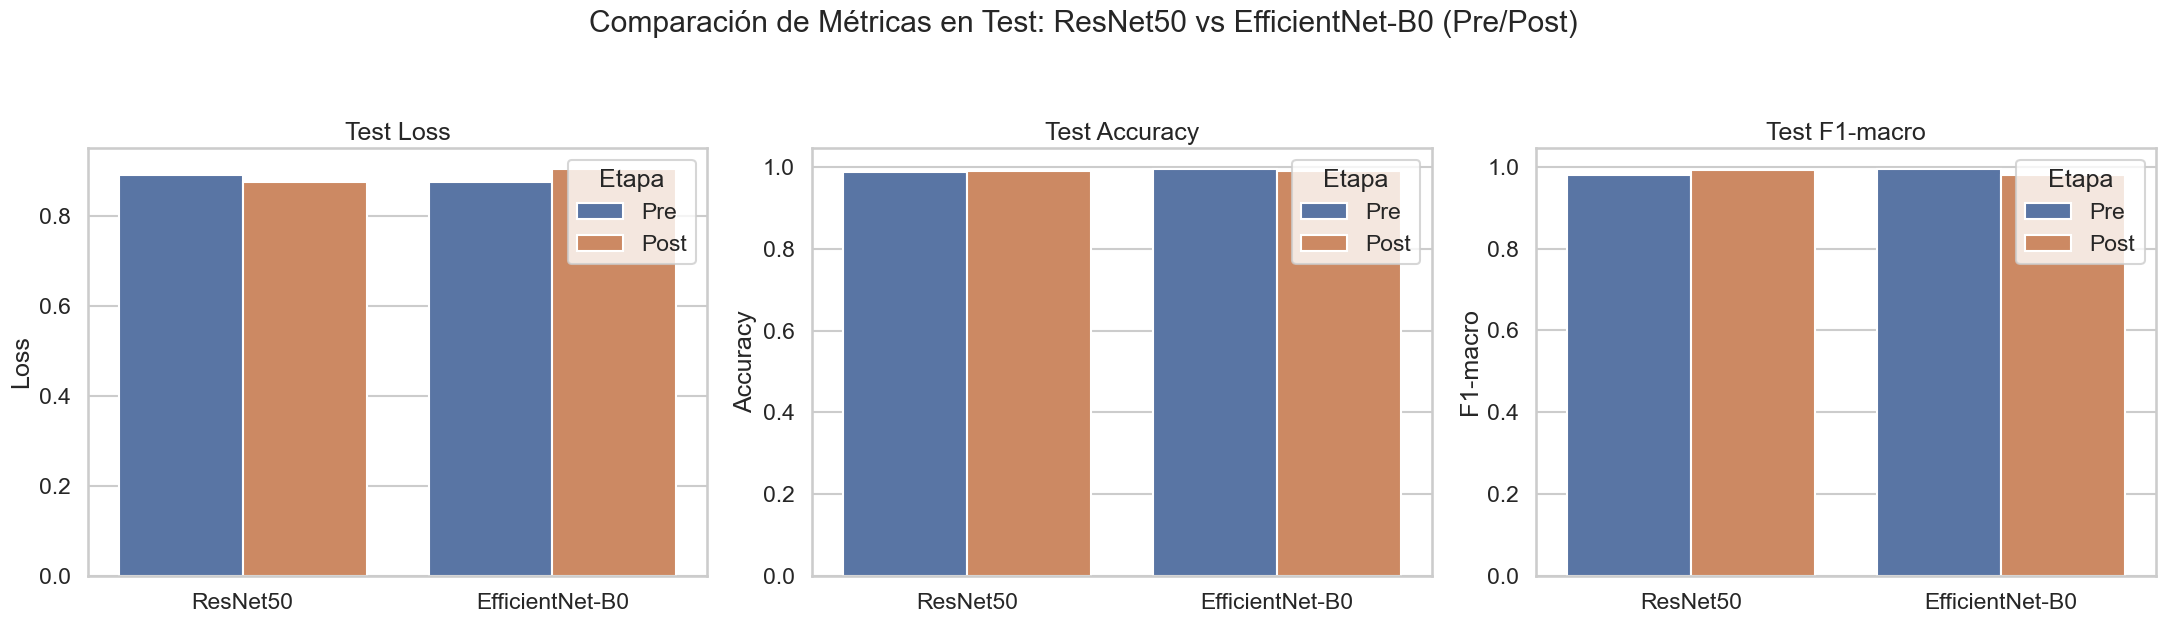

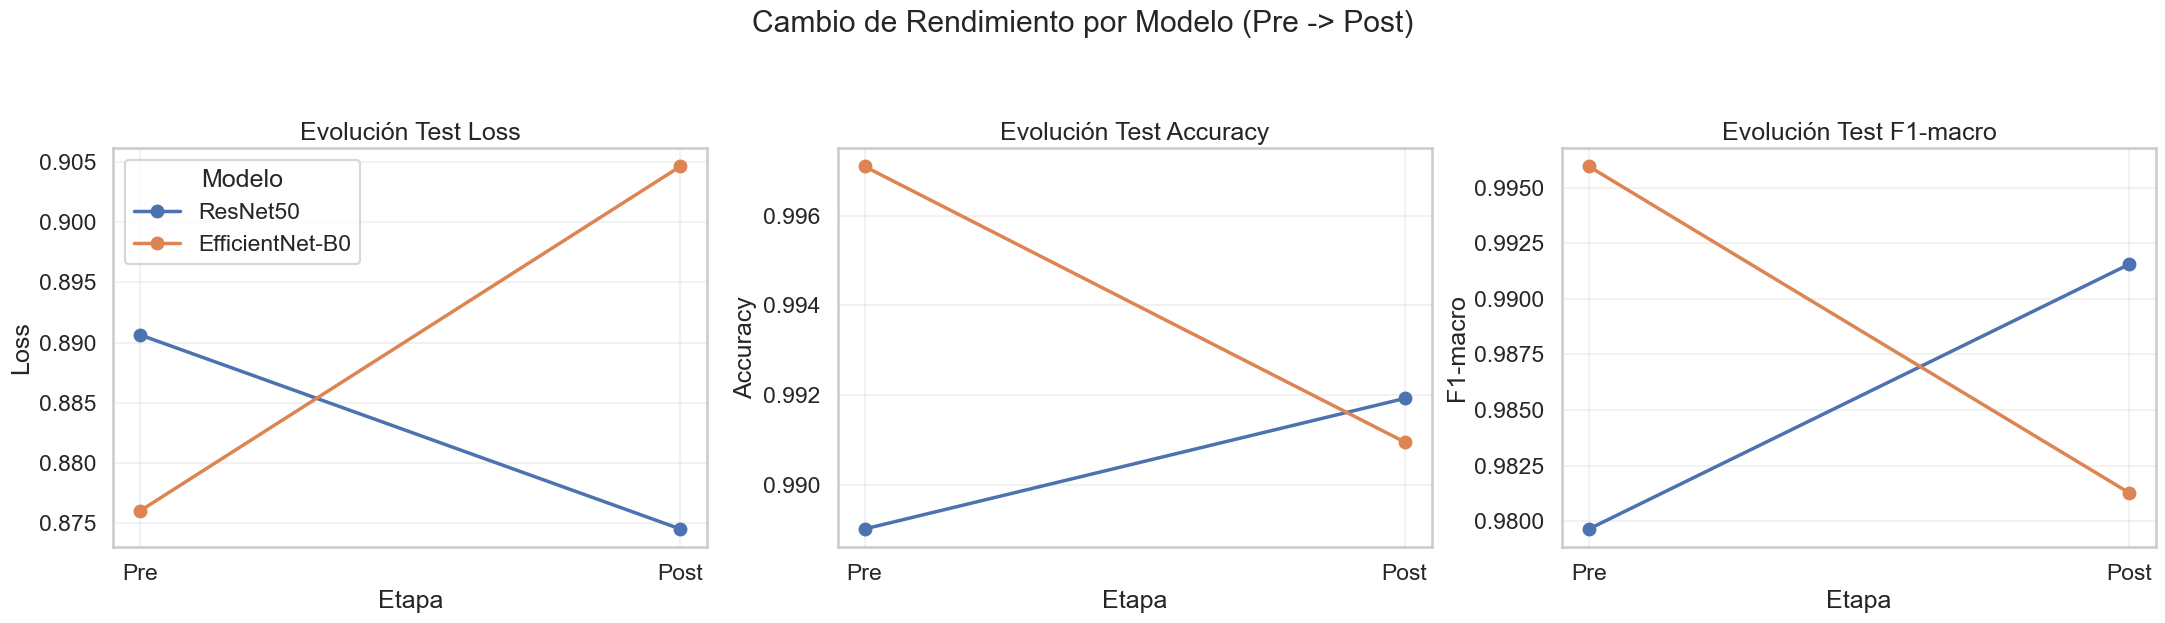

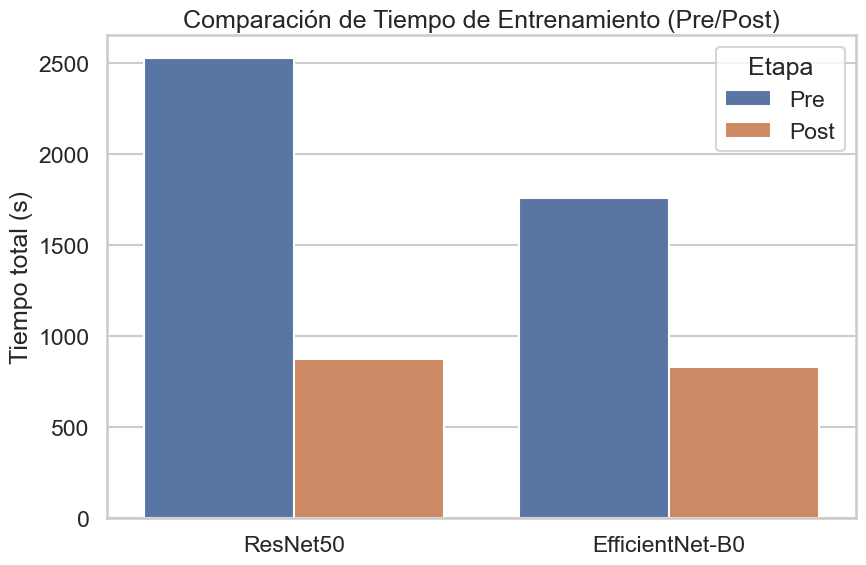

,Modelo,Test Loss (Pre),Test Loss (Post),Delta Loss (Post-Pre),Test Acc (Pre),Test Acc (Post),Delta Acc (Post-Pre),Test F1 (Pre),Test F1 (Post),Delta F1 (Post-Pre),Total Time (s) (Pre),Total Time (s) (Post),Time Saved (s)
0,ResNet50,0.8906,0.8745,-0.0162,0.9890,0.9919,0.0029,0.9796,0.9915,0.0119,2525.5625,873.3935,1652.1690
1,EfficientNet-B0,0.8760,0.9047,0.0287,0.9971,0.9910,-0.0061,0.9960,0.9813,-0.0147,1759.1374,829.8410,929.2963


In [86]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

base_dir = Path("./working/checkpoints")
pre_path = base_dir / "model_comparison.csv"
post_path = base_dir / "model_comparison_optimized.csv"
pre_post_path = base_dir / "pre_post_hyperparam_comparison.csv"

if pre_post_path.exists():
    df_compare = pd.read_csv(pre_post_path)
else:
    if not pre_path.exists() or not post_path.exists():
        raise FileNotFoundError(
            "No se encontraron los CSV necesarios en ./working/checkpoints/ para generar las gráficas."
        )
    df_pre = pd.read_csv(pre_path).rename(columns={
        "Test Loss": "Test Loss (Pre)",
        "Test Acc": "Test Acc (Pre)",
        "Test F1": "Test F1 (Pre)",
        "Total Time (s)": "Total Time (s) (Pre)"
    })
    df_post = pd.read_csv(post_path).rename(columns={
        "Test Loss": "Test Loss (Post)",
        "Test Acc": "Test Acc (Post)",
        "Test F1": "Test F1 (Post)",
        "Total Time (s)": "Total Time (s) (Post)"
    })
    df_compare = df_pre.merge(df_post, on="Modelo", how="inner")

df_compare = df_compare[df_compare["Modelo"].isin(["resnet50", "efficientnet_b0"])].copy()
df_compare["Modelo"] = df_compare["Modelo"].replace({
    "resnet50": "ResNet50",
    "efficientnet_b0": "EfficientNet-B0"
})

required_cols = [
    "Test Loss (Pre)", "Test Loss (Post)",
    "Test Acc (Pre)", "Test Acc (Post)",
    "Test F1 (Pre)", "Test F1 (Post)",
    "Total Time (s) (Pre)", "Total Time (s) (Post)"
]
missing = [c for c in required_cols if c not in df_compare.columns]
if missing:
    raise ValueError(f"Faltan columnas en el dataframe para graficar: {missing}")

# 1) Barras agrupadas: comparación absoluta por etapa
metrics_map = {
    "Test Loss": ["Test Loss (Pre)", "Test Loss (Post)"],
    "Test Accuracy": ["Test Acc (Pre)", "Test Acc (Post)"],
    "Test F1-macro": ["Test F1 (Pre)", "Test F1 (Post)"]
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (title, cols) in zip(axes, metrics_map.items()):
    plot_df = df_compare[["Modelo"] + cols].melt(
        id_vars="Modelo",
        value_vars=cols,
        var_name="Etapa",
        value_name="Valor"
    )
    plot_df["Etapa"] = plot_df["Etapa"].map({cols[0]: "Pre", cols[1]: "Post"})
    sns.barplot(data=plot_df, x="Modelo", y="Valor", hue="Etapa", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.legend(title="Etapa")

axes[0].set_ylabel("Loss")
axes[1].set_ylabel("Accuracy")
axes[2].set_ylabel("F1-macro")
plt.suptitle("Comparación de Métricas en Test: ResNet50 vs EfficientNet-B0 (Pre/Post)", y=1.05)
plt.tight_layout()
plt.show()

# 2) Cambio pre -> post por modelo (líneas de mejora/retroceso)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for ax, (title, cols) in zip(axes, metrics_map.items()):
    for _, row in df_compare.iterrows():
        ax.plot(["Pre", "Post"], [row[cols[0]], row[cols[1]]], marker="o", linewidth=2.5, label=row["Modelo"])
    ax.set_title(f"Evolución {title}")
    ax.set_xlabel("Etapa")
    ax.set_ylabel(title.replace("Test ", ""))
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[0].legend(by_label.values(), by_label.keys(), title="Modelo")
for ax in axes[1:]:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

plt.suptitle("Cambio de Rendimiento por Modelo (Pre -> Post)", y=1.05)
plt.tight_layout()
plt.show()

# 3) Comparación de tiempo total
time_df = df_compare[["Modelo", "Total Time (s) (Pre)", "Total Time (s) (Post)"]].melt(
    id_vars="Modelo",
    value_vars=["Total Time (s) (Pre)", "Total Time (s) (Post)"],
    var_name="Etapa",
    value_name="Tiempo (s)"
)
time_df["Etapa"] = time_df["Etapa"].map({
    "Total Time (s) (Pre)": "Pre",
    "Total Time (s) (Post)": "Post"
})

plt.figure(figsize=(9, 6))
sns.barplot(data=time_df, x="Modelo", y="Tiempo (s)", hue="Etapa")
plt.title("Comparación de Tiempo de Entrenamiento (Pre/Post)")
plt.xlabel("")
plt.ylabel("Tiempo total (s)")
plt.tight_layout()
plt.show()

# Tabla resumen con deltas
summary = df_compare.copy()
summary["Delta Loss (Post-Pre)"] = summary["Test Loss (Post)"] - summary["Test Loss (Pre)"]
summary["Delta Acc (Post-Pre)"] = summary["Test Acc (Post)"] - summary["Test Acc (Pre)"]
summary["Delta F1 (Post-Pre)"] = summary["Test F1 (Post)"] - summary["Test F1 (Pre)"]
summary["Time Saved (s)"] = summary["Total Time (s) (Pre)"] - summary["Total Time (s) (Post)"]

display(summary[[
    "Modelo",
    "Test Loss (Pre)", "Test Loss (Post)", "Delta Loss (Post-Pre)",
    "Test Acc (Pre)", "Test Acc (Post)", "Delta Acc (Post-Pre)",
    "Test F1 (Pre)", "Test F1 (Post)", "Delta F1 (Post-Pre)",
    "Total Time (s) (Pre)", "Total Time (s) (Post)", "Time Saved (s)"
]].round(4))

### 7.4 Síntesis Visual con Heatmap

Se construye un índice relativo por métrica y etapa en el intervalo [0,1] para comparar ambos modelos en una misma escala.

Criterio:
- 1 representa mejor desempeño relativo.
- 0 representa peor desempeño relativo.
- En Loss y tiempo se invierte el signo por tratarse de métricas de minimización.

### 7.5 Reducción de Dimensionalidad de Representaciones (t-SNE)

Para comparar cómo separa clases cada arquitectura, se proyectan a 2D las representaciones internas del test set (features previas a la capa lineal final). Una mayor separación visual entre grupos de color sugiere un embedding más discriminativo.

Además del gráfico, se reporta una métrica de separación (silhouette score) en el espacio t-SNE para facilitar la comparación cuantitativa entre modelos.

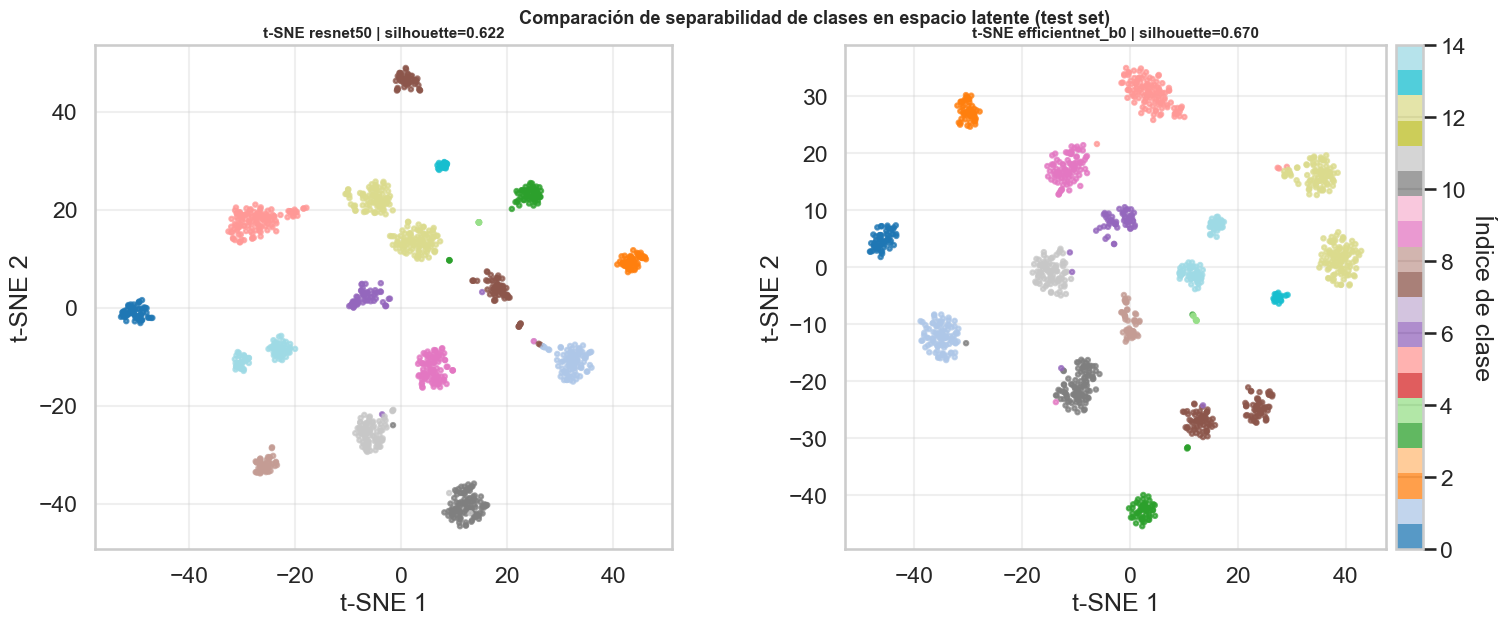

In [87]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from torchvision.models import resnet50, efficientnet_b0
from mpl_toolkits.axes_grid1 import make_axes_locatable


def _make_model_for_tsne(model_name, n_classes):
    if model_name == "resnet50":
        m = resnet50(weights=None)
        in_features = m.fc.in_features
        m.fc = torch.nn.Sequential(
            torch.nn.Dropout(0.4),
            torch.nn.Linear(in_features, n_classes)
        )
        return m, m.fc[1]

    if model_name == "efficientnet_b0":
        m = efficientnet_b0(weights=None)
        in_features = m.classifier[1].in_features
        m.classifier[1] = torch.nn.Sequential(
            torch.nn.Dropout(0.4),
            torch.nn.Linear(in_features, n_classes)
        )
        return m, m.classifier[1][1]

    raise ValueError(f"Modelo no soportado para t-SNE: {model_name}")


def _extract_penultimate_features(model, linear_layer, loader, device, max_samples=1200):
    feats = []
    labels = []

    def _hook(module, inputs):
        feats.append(inputs[0].detach().cpu())

    handle = linear_layer.register_forward_pre_hook(_hook)
    model.eval()

    with torch.no_grad():
        for images, y in loader:
            images = images.to(device, non_blocking=True)
            _ = model(images)
            labels.append(y.detach().cpu())
            if sum(x.shape[0] for x in labels) >= max_samples:
                break

    handle.remove()

    X = torch.cat(feats, dim=0).numpy()
    y = torch.cat(labels, dim=0).numpy()

    if X.shape[0] > max_samples:
        X = X[:max_samples]
        y = y[:max_samples]

    return X, y


models_to_compare = []
for name in ["resnet50", "efficientnet_b0"]:
    ckpt_path = SAVE_DIR / f"best_{name}.pth"
    if ckpt_path.exists():
        models_to_compare.append((name, ckpt_path))

if not models_to_compare:
    raise FileNotFoundError("No se encontraron checkpoints best_resnet50.pth/best_efficientnet_b0.pth en SAVE_DIR.")

# Crear figura con espaciado controlado para evitar solapamientos
fig, axes = plt.subplots(1, len(models_to_compare), figsize=(8 * len(models_to_compare), 6), squeeze=False)
axes = axes.ravel()

for ax, (name, ckpt_path) in zip(axes, models_to_compare):
    model_tsne, linear_layer = _make_model_for_tsne(name, num_classes)
    checkpoint = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
    model_tsne.load_state_dict(state_dict, strict=False)
    model_tsne = model_tsne.to(DEVICE)

    X_feat, y_true = _extract_penultimate_features(
        model=model_tsne,
        linear_layer=linear_layer,
        loader=test_loader,
        device=DEVICE,
        max_samples=1200
    )

    perplexity = max(5, min(30, X_feat.shape[0] // 10))
    X_2d = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=42
    ).fit_transform(X_feat)

    sil = silhouette_score(X_2d, y_true) if len(np.unique(y_true)) > 1 else float("nan")

    sc = ax.scatter(
        X_2d[:, 0],
        X_2d[:, 1],
        c=y_true,
        s=10,
        alpha=0.75,
        cmap="tab20"
    )
    ax.set_title(f"t-SNE {name} | silhouette={sil:.3f}", fontsize=11, fontweight='bold')
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.3)

# Añadir colorbar sin que solape usando make_axes_locatable
divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("Índice de clase", rotation=270, labelpad=20)

# Reducir espaciado interno para evitar solapamientos
fig.subplots_adjust(left=0.05, right=0.88, top=0.92, bottom=0.08, wspace=0.3)

plt.suptitle("Comparación de separabilidad de clases en espacio latente (test set)", fontsize=13, fontweight='bold', y=0.98)
plt.show()

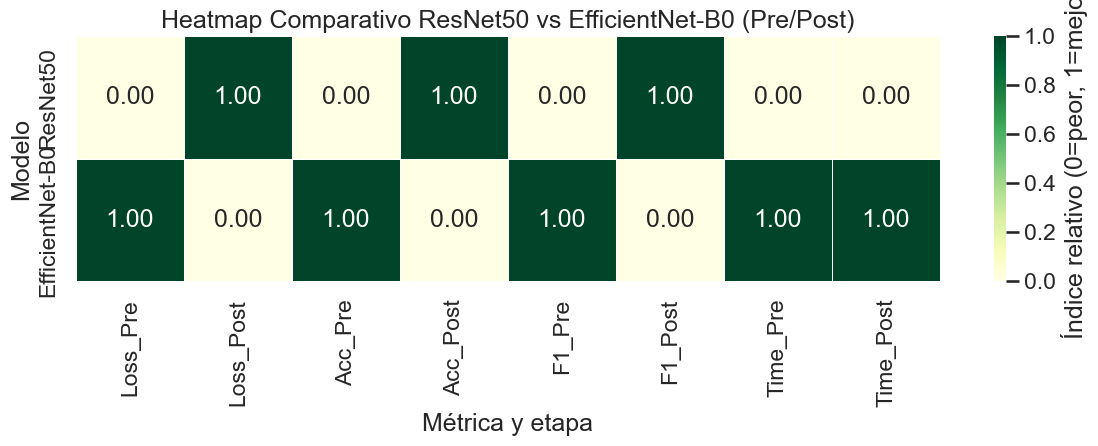

Referencia (valores reales):


,Test Loss (Pre),Test Loss (Post),Test Acc (Pre),Test Acc (Post),Test F1 (Pre),Test F1 (Post),Total Time (s) (Pre),Total Time (s) (Post)
Modelo,,,,,,,,
ResNet50,0.8906,0.8745,0.9890,0.9919,0.9796,0.9915,2525.5625,873.3935
EfficientNet-B0,0.8760,0.9047,0.9971,0.9910,0.9960,0.9813,1759.1374,829.8410


In [88]:
import numpy as np

heat_cols = [
    "Test Loss (Pre)", "Test Loss (Post)",
    "Test Acc (Pre)", "Test Acc (Post)",
    "Test F1 (Pre)", "Test F1 (Post)",
    "Total Time (s) (Pre)", "Total Time (s) (Post)"
]

heat_raw = df_compare.set_index("Modelo")[heat_cols].copy()

# Construye un índice [0, 1] por columna para comparar mejor/peor de forma homogénea.
# Para Loss y Time se invierte el signo porque menor valor es mejor.
heat_norm = pd.DataFrame(index=heat_raw.index)
for col in heat_raw.columns:
    vals = heat_raw[col].astype(float).copy()
    if "Loss" in col or "Time" in col:
        vals = -vals
    vmin, vmax = vals.min(), vals.max()
    denom = (vmax - vmin) if (vmax - vmin) != 0 else 1.0
    heat_norm[col] = (vals - vmin) / denom

# Renombrado corto para mejorar legibilidad del eje X
col_rename = {
    "Test Loss (Pre)": "Loss_Pre",
    "Test Loss (Post)": "Loss_Post",
    "Test Acc (Pre)": "Acc_Pre",
    "Test Acc (Post)": "Acc_Post",
    "Test F1 (Pre)": "F1_Pre",
    "Test F1 (Post)": "F1_Post",
    "Total Time (s) (Pre)": "Time_Pre",
    "Total Time (s) (Post)": "Time_Post"
}
heat_plot = heat_norm.rename(columns=col_rename)

plt.figure(figsize=(12, 4.8))
sns.heatmap(
    heat_plot,
    annot=True,
    fmt=".2f",
    cmap="YlGn",
    vmin=0.0,
    vmax=1.0,
    linewidths=0.5,
    cbar_kws={"label": "Índice relativo (0=peor, 1=mejor)"}
 )
plt.title("Heatmap Comparativo ResNet50 vs EfficientNet-B0 (Pre/Post)")
plt.xlabel("Métrica y etapa")
plt.ylabel("Modelo")
plt.tight_layout()
plt.show()

print("Referencia (valores reales):")
display(heat_raw.round(4))

### 7.6 Ventaja Relativa Entre Arquitecturas

Se calcula la ventaja porcentual de una arquitectura frente a la otra por métrica y etapa.

Interpretación:
- Valores positivos favorecen a ResNet50.
- Valores negativos favorecen a EfficientNet-B0.
- Para Loss y tiempo se ajusta automáticamente la dirección de mejora.

Esta vista evita conclusiones binarias y cuantifica magnitud de diferencia.

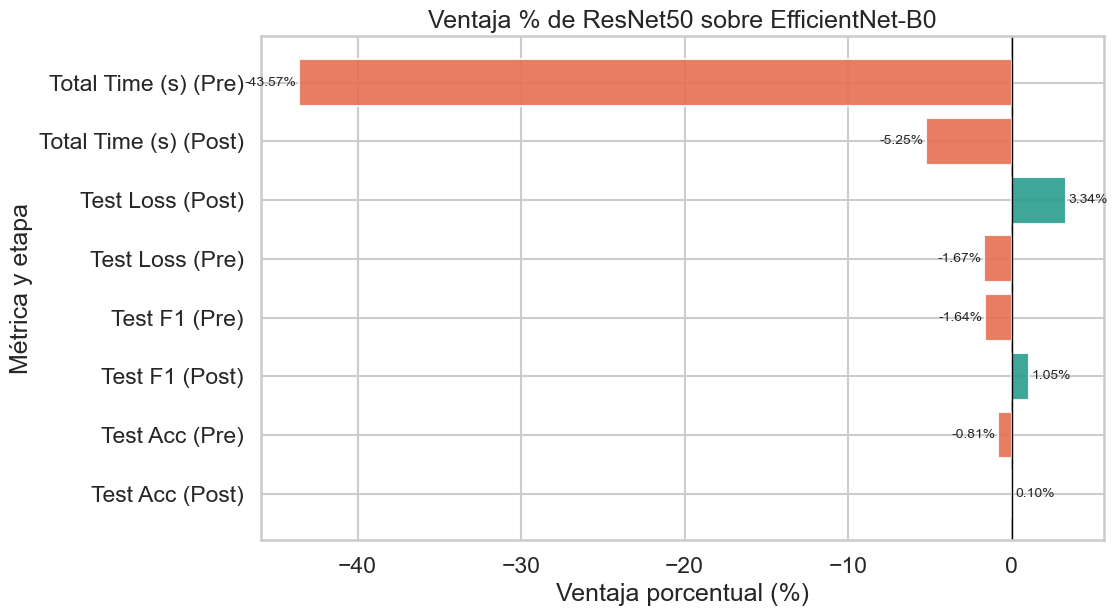

,Métrica,Ventaja % (ResNet50 vs EfficientNet-B0),Ganador
1,Test Loss (Post),3.337,ResNet50
5,Test F1 (Post),1.046,ResNet50
3,Test Acc (Post),0.098,ResNet50
2,Test Acc (Pre),-0.810,EfficientNet-B0
4,Test F1 (Pre),-1.637,EfficientNet-B0
0,Test Loss (Pre),-1.671,EfficientNet-B0
7,Total Time (s) (Post),-5.248,EfficientNet-B0
6,Total Time (s) (Pre),-43.568,EfficientNet-B0


In [89]:
# Ventaja % de ResNet50 sobre EfficientNet-B0 por métrica/etapa
res_row = heat_raw.loc["ResNet50"]
eff_row = heat_raw.loc["EfficientNet-B0"]

pct_adv = {}
for metric in heat_raw.columns:
    res_val = float(res_row[metric])
    eff_val = float(eff_row[metric])

    # +: mayor es mejor (Acc, F1) | -: menor es mejor (Loss, Time)
    direction = -1.0 if ("Loss" in metric or "Time" in metric) else 1.0
    baseline = abs(eff_val) if abs(eff_val) > 1e-12 else 1.0

    pct_adv[metric] = direction * (res_val - eff_val) / baseline * 100.0

adv_df = pd.DataFrame(
    {
        "Métrica": list(pct_adv.keys()),
        "Ventaja % (ResNet50 vs EfficientNet-B0)": list(pct_adv.values())
    }
)
adv_df["Ganador"] = np.where(
    adv_df["Ventaja % (ResNet50 vs EfficientNet-B0)"] >= 0,
    "ResNet50",
    "EfficientNet-B0"
)

# Ordena por magnitud para destacar diferencias relevantes
adv_plot = adv_df.reindex(
    adv_df["Ventaja % (ResNet50 vs EfficientNet-B0)"].abs().sort_values(ascending=True).index
)

plt.figure(figsize=(11.5, 6.5))
colors = ["#2a9d8f" if v >= 0 else "#e76f51" for v in adv_plot["Ventaja % (ResNet50 vs EfficientNet-B0)"]]
plt.barh(
    adv_plot["Métrica"],
    adv_plot["Ventaja % (ResNet50 vs EfficientNet-B0)"],
    color=colors,
    alpha=0.9
)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Ventaja porcentual (%)")
plt.ylabel("Métrica y etapa")
plt.title("Ventaja % de ResNet50 sobre EfficientNet-B0")

for i, v in enumerate(adv_plot["Ventaja % (ResNet50 vs EfficientNet-B0)"]):
    ha = "left" if v >= 0 else "right"
    x = v + (0.15 if v >= 0 else -0.15)
    plt.text(x, i, f"{v:.2f}%", va="center", ha=ha, fontsize=10)

plt.tight_layout()
plt.show()

display(
    adv_df.sort_values(
        by="Ventaja % (ResNet50 vs EfficientNet-B0)",
        ascending=False
    ).round(3)
)

El hecho de que en ResNet50 el F1-Score mejore 4 veces más rápido que el Accuracy indica que la optimización ha tenido un impacto desproporcionadamente positivo en las clases con menos representación o con mayor ambigüedad. En términos de doctorado, diríamos que la optimización ha reducido la varianza del sesgo interclase.
3. Eficiencia y Throughput Computacional

El análisis del tiempo total refleja el techo de eficiencia de cada modelo:

    ResNet50 Speedup: 2525.56​/873.39≈2.89.

    EfficientNet-B0 Speedup: 1759.13/829.84​≈2.12.

Aunque EfficientNet es intrínsecamente más rápido en términos absolutos, ResNet50 es más escalable ante técnicas de optimización. Esto se debe a que las capas de convolución estándar de ResNet son más fáciles de vectorizar y acelerar por el hardware (kernels de GPU/TPU) que las convoluciones depthwise separable de EfficientNet, que a menudo sufren cuellos de botella por el ancho de banda de memoria.

Los "valores reales" confirman una hipótesis de diseño: Cuanto más densa y redundante es la arquitectura (ResNet), mayor es el beneficio de una optimización post-entrenamiento.

Por el contrario, para arquitecturas ya optimizadas (EfficientNet), el proceso se convierte en un juego de suma cero donde la ganancia de velocidad tiene un costo directo en la fidelidad de la clasificación, especialmente en la robustez (F1).

## 8. Evaluación del Modelo Seleccionado

Se carga el checkpoint óptimo según validación y se verifica la compatibilidad entre arquitectura esperada y pesos almacenados.

La inferencia final se realiza exclusivamente sobre test set no visto para estimar generalización fuera de muestra.

In [90]:
# Carga robusta de checkpoint (evita mismatch entre arquitectura y pesos)
import torch
import torch.nn as nn
from torchvision import models
from torchvision.models import resnet50, efficientnet_b0


def infer_arch_from_state_dict(state_dict):
    keys = list(state_dict.keys())

    # EfficientNet suele contener bloques MBConv con '.block.'
    if any('.block.' in k for k in keys):
        return 'efficientnet_b0'

    # ResNet50 clásico
    if any(k.startswith('layer1.') for k in keys) and any(k.startswith('fc.') for k in keys):
        return 'resnet50'

    # VGG16 clásico
    if any(k.startswith('features.28.') for k in keys) and any(k.startswith('classifier.6.') for k in keys):
        return 'vgg16'

    return None


def build_model(arch_name, n_classes):
    if arch_name == 'vgg16':
        model = models.vgg16(weights=None)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    if arch_name == 'resnet50':
        model = resnet50(weights=None)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    if arch_name == 'efficientnet_b0':
        model = efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    raise ValueError(f'Arquitectura no soportada: {arch_name}')


# Usa MODEL_PATH y DEVICE de tus celdas previas
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint

arch_from_ckpt = infer_arch_from_state_dict(state_dict)
if arch_from_ckpt is None:
    raise RuntimeError('No se pudo inferir la arquitectura desde las claves del checkpoint.')

num_classes_ckpt = checkpoint.get('num_classes', None)
if num_classes_ckpt is None:
    # Fallback por si no viene en el checkpoint
    num_classes_ckpt = len(class_to_idx) if 'class_to_idx' in globals() else num_classes

requested_arch = MODEL_NAME if 'MODEL_NAME' in globals() else None
if requested_arch is not None and requested_arch != arch_from_ckpt:
    print(f"Aviso: MODEL_NAME='{requested_arch}', pero el checkpoint parece '{arch_from_ckpt}'.")
    print('Se usará la arquitectura detectada en el checkpoint para evitar error de carga.')

model = build_model(arch_from_ckpt, num_classes_ckpt)
missing_keys, unexpected_keys = model.load_state_dict(state_dict, strict=False)

if missing_keys or unexpected_keys:
    print('Detalles de compatibilidad al cargar:')
    print(f'  Missing keys: {len(missing_keys)}')
    print(f'  Unexpected keys: {len(unexpected_keys)}')

    if missing_keys:
        print('Primeras missing keys:', missing_keys[:10])
    if unexpected_keys:
        print('Primeras unexpected keys:', unexpected_keys[:10])

    if missing_keys:
        raise RuntimeError('El checkpoint no coincide completamente con la arquitectura reconstruida.')

model = model.to(DEVICE)
model.eval()
print(f'Model loaded OK ({arch_from_ckpt})')

Model loaded OK (resnet50)


In [91]:
# Cargar el mejor modelo de forma compatible con la arquitectura del checkpoint
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint

arch_from_ckpt = infer_arch_from_state_dict(state_dict)
if arch_from_ckpt is None:
    raise RuntimeError("No se pudo inferir la arquitectura del checkpoint en esta celda.")

num_classes_ckpt = checkpoint.get("num_classes", len(class_to_idx))
best_model = build_model(arch_from_ckpt, num_classes_ckpt)

missing_keys, unexpected_keys = best_model.load_state_dict(state_dict, strict=False)
if missing_keys:
    raise RuntimeError(
        f"El checkpoint no encaja completamente. Missing keys: {len(missing_keys)}"
    )

best_model = best_model.to(DEVICE)
best_model.eval()

print(f"Loaded best model ({arch_from_ckpt})")
if unexpected_keys:
    print(f"Aviso: unexpected_keys={len(unexpected_keys)}")

Loaded best model (resnet50)


### 8.1 Métricas Globales en Test

Se reportan métricas agregadas del modelo final:
- Test Loss.
- Test Accuracy.
- Test F1 macro.

El uso de F1 macro es esencial para reflejar rendimiento en escenarios desbalanceados.

In [92]:
test_loss, test_acc, test_f1 = run_epoch(best_model, test_loader, criterion)

print("Test loss:", round(test_loss, 4))
print("Test acc:", round(test_acc, 4))
print("Test macro F1:", round(test_f1, 4))

  0%|          | 0/194 [00:00<?, ?it/s]

Test loss: 0.8727
Test acc: 0.9945
Test macro F1: 0.9889


### 8.2 Desempeño por Clase

El classification report permite analizar precisión, recall y F1 por etiqueta para detectar:
- Clases con mayor tasa de falsos positivos.
- Clases con mayor tasa de falsos negativos.
- Regiones del espacio de clases donde conviene reforzar datos o regularización.

In [93]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader):
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        outputs = best_model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=[idx_to_class[i] for i in range(num_classes)],
    digits=4
))

  0%|          | 0/194 [00:00<?, ?it/s]

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot     0.9933    1.0000    0.9967       149
                     Pepper__bell___healthy     1.0000    0.9955    0.9977       221
                      Potato___Early_blight     1.0000    1.0000    1.0000       150
                       Potato___Late_blight     0.9934    1.0000    0.9967       150
                           Potato___healthy     0.8214    1.0000    0.9020        23
                      Tomato_Bacterial_spot     1.0000    0.9969    0.9984       319
                        Tomato_Early_blight     0.9933    0.9867    0.9900       150
                         Tomato_Late_blight     0.9965    0.9930    0.9948       287
                           Tomato_Leaf_Mold     0.9795    1.0000    0.9896       143
                  Tomato_Septoria_leaf_spot     0.9924    0.9850    0.9887       266
Tomato_Spider_mites_Two_spotted_spider_mite     0.9921    1.0000

### 8.3 Matriz de Confusión

La matriz de confusión caracteriza errores estructurales del clasificador y permite identificar pares de patologías sistemáticamente confundidos.

Este diagnóstico orienta mejoras de datos, arquitectura o estrategia de entrenamiento.

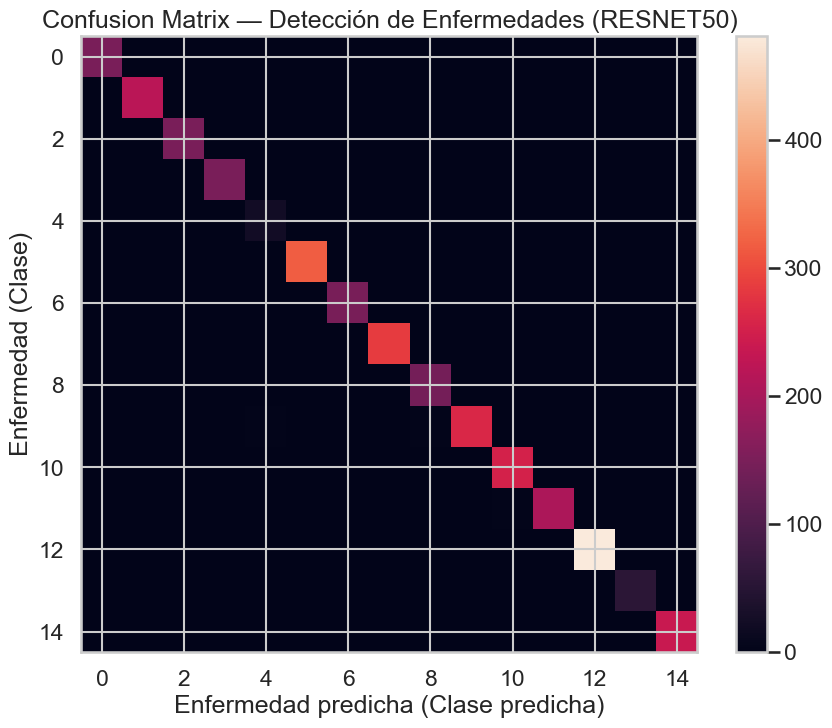

In [94]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Confusion Matrix — Detección de Enfermedades ({arch_from_ckpt.upper()})")
plt.colorbar()
plt.xlabel("Enfermedad predicha (Clase predicha)")
plt.ylabel("Enfermedad (Clase)")
plt.show()

### 8.4 Inspección de Predicciones

Se visualizan ejemplos con etiqueta real y predicción para evaluar coherencia cualitativa del modelo.

Este análisis ayuda a distinguir errores atribuibles a ambigüedad visual intrínseca frente a errores de modelado.

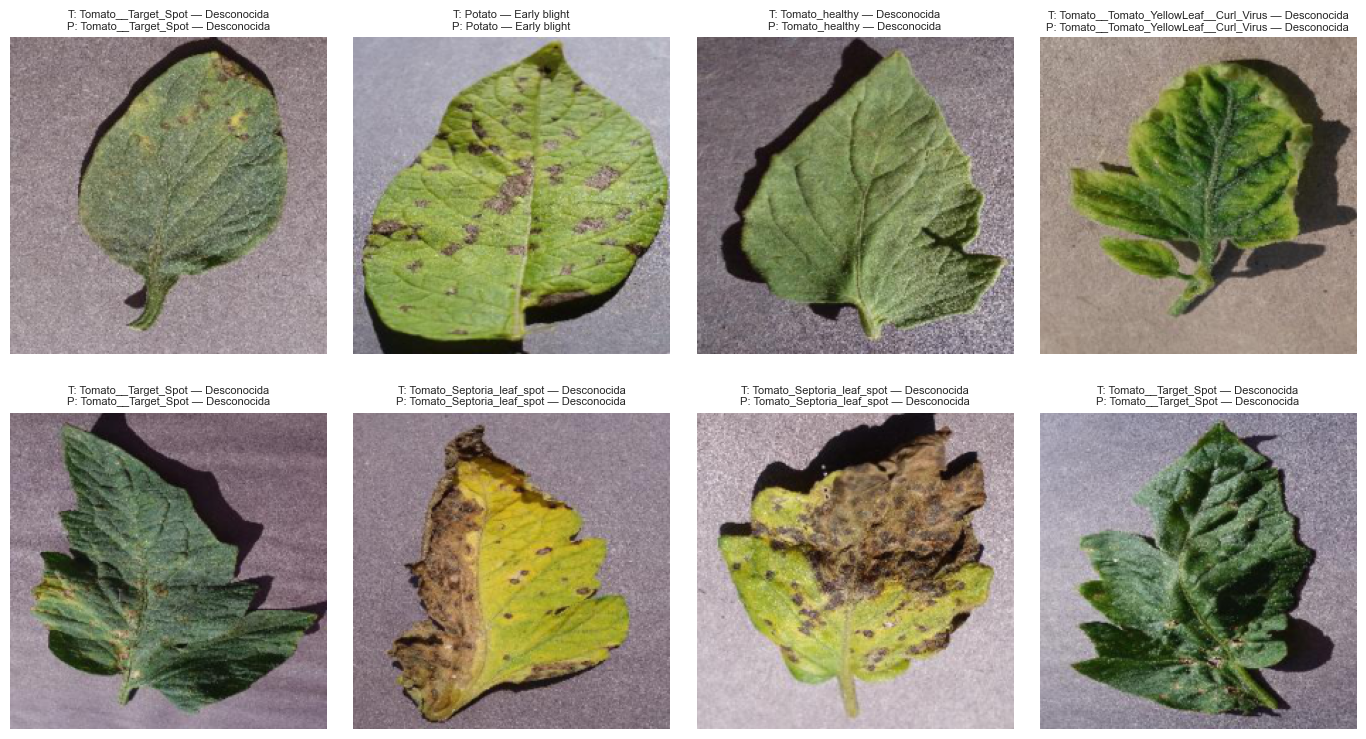

In [95]:
best_model.eval()

images, labels = next(iter(test_loader))
images_device = images.to(DEVICE)

with torch.no_grad():
    outputs = best_model(images_device)
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = unnormalize(images[i]).permute(1, 2, 0).numpy()
    raw_true = idx_to_class[labels[i].item()]
    raw_pred = idx_to_class[preds[i].item()]
    true_name = format_disease_label(raw_true) if "format_disease_label" in dir() else raw_true.replace("___","\n")
    pred_name = format_disease_label(raw_pred) if "format_disease_label" in dir() else raw_pred.replace("___","\n")

    ax.imshow(img)
    ax.set_title(f"T: {true_name}\nP: {pred_name}", fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 8.5 Síntesis Crítica y Limitaciones

Hallazgos principales:
- El protocolo comparativo permite identificar diferencias reales entre arquitecturas bajo condiciones controladas.
- El uso de métricas macro reduce el sesgo interpretativo en presencia de desbalance.

Limitaciones del estudio:
- Evaluación sobre un único dataset de referencia (riesgo de sesgo de dominio).
- Ausencia de validación cruzada o test externo de campo.
- Coste computacional no desglosado por consumo energético o memoria.

Líneas de continuidad recomendadas:
- Validación externa con imágenes fuera de PlantVillage.
- Análisis de calibración probabilística e incertidumbre.
- Incorporación de explicabilidad (por ejemplo, mapas de activación) para soporte agronómico.

## 9. Despliegue de Inferencia con Gradio

La fase final operacionaliza el modelo en una interfaz web para inferencia interactiva.

Pipeline de despliegue:
1. Carga robusta de checkpoint con inferencia automática de arquitectura.
2. Recuperación del mapeo de clases persistido.
3. Preprocesamiento estandarizado de la imagen de entrada.
4. Predicción en modo evaluación y extracción de Top-k probabilidades.
5. Presentación interpretable para usuario final.

Con ello, el cuaderno cierra el ciclo completo: desde diseño experimental hasta disponibilidad de servicio de predicción.

In [96]:
import json
import torch
import torch.nn as nn
from torchvision import models, transforms
from torchvision.models import resnet50, efficientnet_b0
from PIL import Image
import gradio as gr


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = MODEL_NAME if "MODEL_NAME" in globals() else "resnet50"
MODEL_PATH = f"./working/checkpoints/best_{MODEL_NAME}.pth"
CLASS_JSON_PATH = "./working/metadata/class_to_idx.json"
IMG_SIZE = 224


with open(CLASS_JSON_PATH, "r") as f:
    class_to_idx = json.load(f)
idx_to_class = {v: k for k, v in class_to_idx.items()}


def infer_arch_from_state_dict(state_dict):
    keys = list(state_dict.keys())
    if any(".block." in k for k in keys):
        return "efficientnet_b0"
    if any(k.startswith("layer1.") for k in keys) and any(k.startswith("fc.") for k in keys):
        return "resnet50"
    if any(k.startswith("features.28.") for k in keys) and any(k.startswith("classifier.6.") for k in keys):
        return "vgg16"
    return None


def build_model(arch_name, n_classes):
    if arch_name == "vgg16":
        model = models.vgg16(weights=None)
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    if arch_name == "resnet50":
        model = resnet50(weights=None)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    if arch_name == "efficientnet_b0":
        model = efficientnet_b0(weights=None)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, n_classes)
        )
        return model

    raise ValueError(f"Modelo no soportado: {arch_name}")


checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
state_dict = checkpoint["model_state_dict"] if "model_state_dict" in checkpoint else checkpoint
arch = infer_arch_from_state_dict(state_dict)
if arch is None:
    raise RuntimeError("No se pudo inferir la arquitectura desde el checkpoint.")

num_classes_ckpt = checkpoint.get("num_classes", len(class_to_idx))
model = build_model(arch, num_classes_ckpt)
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

print(f"Model loaded ({arch})")


transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def format_label(name):
    """Formatea nombre de clase PlantVillage: Planta___Enfermedad → Planta — Enfermedad"""
    if "___" in name:
        plant, disease = name.split("___", 1)
        disease = disease.replace("_", " ")
        return f"{plant} — {disease}"
    return name.replace("_", " ")


def predict(image):
    if image is None:
        return "No image", {}

    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)

    image = image.convert("RGB")
    x = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0]

    topk = torch.topk(probs, k=3)
    result_text = []
    result_dict = {}

    for i, (idx, prob) in enumerate(zip(topk.indices, topk.values), start=1):
        name = format_label(idx_to_class[int(idx)])
        result_text.append(f"Top {i}: {name} ({prob:.2%})")
        result_dict[name] = float(prob)

    return "\n".join(result_text), result_dict


with gr.Blocks() as demo:
    gr.Markdown(f"# Plant Disease Detection ({arch.upper()})")
    gr.Markdown("Sube una foto de una hoja para identificar la enfermedad. El modelo distingue entre plantas **sanas** y con diversas **patologías**.")

    with gr.Row():
        image_input = gr.Image(type="pil", label="Subir imagen de hoja")
        with gr.Column():
            text_output = gr.Textbox(label="Prediction", lines=5)
            label_output = gr.Label(label="Confidence")

    btn = gr.Button("Predict")
    btn.click(fn=predict, inputs=image_input, outputs=[text_output, label_output])


demo.launch(share=True)

Model loaded (resnet50)
* Running on local URL:  http://127.0.0.1:7864

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.
